# Predição do cumprimento de metas de produtividade

O objetivo é prever se uma equipe vai ou não atingir a meta de produtividade.

- `0`: atingiu a meta
- `1`: não atingiu a meta

Serão comparados dois modelos: **Regressão Logística** e **KNN**.


In [31]:
import warnings
warnings.filterwarnings("ignore")

import sys
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, make_scorer
)

# No Colab abre a seleção do arquivo.
try:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(next(iter(uploaded)))
except ImportError:
    df = pd.read_csv("dataset.csv")

print("Versões do ambiente:")
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("\nDimensões originais:", df.shape)


Saving dataset.csv to dataset (2).csv
Versões do ambiente:
Python: 3.13.15
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1

Dimensões originais: (1197, 15)


## 1. Preparação dos dados

Os textos são padronizados, a data é convertida e a variável `risco_meta` é criada.

`actual_productivity` é usada apenas para criar o alvo e não entra nos modelos.


In [32]:
df.columns = df.columns.str.strip().str.lower()

for c in ["quarter", "department", "day"]:
    df[c] = df[c].astype("string").str.strip().str.lower()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["risco_meta"] = (
    df["actual_productivity"] < df["targeted_productivity"]
).astype(int)

# Ordem cronológica.
df = df.sort_values("date").reset_index(drop=True)

print("Datas inválidas:", df["date"].isna().sum())
print("Duplicatas:", df.duplicated().sum())

# Teste final: datas mais recentes.
data_corte = df.iloc[int(len(df) * 0.80)]["date"]
df_dev = df[df["date"] < data_corte].copy()
df_test = df[df["date"] >= data_corte].copy()

# A base já está em ordem cronológica; apenas reinicia o índice.
df_dev = df_dev.reset_index(drop=True)

# Treino e validação também seguem o tempo.
data_corte_val = df_dev.iloc[int(len(df_dev) * 0.80)]["date"]
df_train = df_dev[df_dev["date"] < data_corte_val].copy()
df_val = df_dev[df_dev["date"] >= data_corte_val].copy()

print("Corte treino/validação:", data_corte_val.date())
print("Corte desenvolvimento/teste:", data_corte.date())
print("Treino:", len(df_train), "| Validação:", len(df_val),
      "| Teste:", len(df_test))


Datas inválidas: 0
Duplicatas: 0
Corte treino/validação: 2015-02-14
Corte desenvolvimento/teste: 2015-02-26
Treino: 749 | Validação: 194 | Teste: 254


## 2. Análise exploratória

Nesta etapa são verificados distribuição das classes, valores ausentes, divisão temporal, estatísticas descritivas e possíveis outliers.


,Quantidade,Percentual (%)
risco_meta,,
0,875,73.1
1,322,26.9


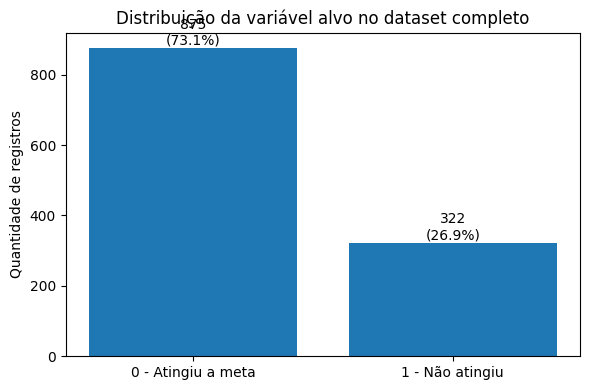

,Quantidade,Percentual (%)
wip,391,41.46
date,0,0.00
department,0,0.00
quarter,0,0.00
day,0,0.00
team,0,0.00
targeted_productivity,0,0.00
smv,0,0.00
over_time,0,0.00
incentive,0,0.00


,sum,count
department,,
finishing,391,391
sweing,0,552


,Conjunto,Registros,Proporção do total (%),Classe 0 (%),Classe 1 (%)
0,Treino,749,62.57,76.64,23.36
1,Validação,194,16.21,59.28,40.72
2,Teste,254,21.22,73.23,26.77


In [33]:
# Distribuição da classe alvo
classes = df["risco_meta"].value_counts().sort_index()
percentuais = classes / len(df) * 100

tabela_classes = pd.DataFrame({
    "Quantidade": classes,
    "Percentual (%)": percentuais.round(2)
})
display(tabela_classes)

# Distribuição da classe alvo
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(
    ["0 - Atingiu a meta", "1 - Não atingiu"],
    classes.values
)
ax.set_title("Distribuição da variável alvo no dataset completo")
ax.set_ylabel("Quantidade de registros")

for barra, qtd, pct in zip(barras, classes.values, percentuais.values):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 10,
        f"{qtd}\n({pct:.1f}%)",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Valores ausentes no desenvolvimento
nulos = pd.DataFrame({
    "Quantidade": df_dev.isna().sum(),
    "Percentual (%)": (df_dev.isna().mean() * 100).round(2)
}).sort_values("Quantidade", ascending=False)

display(nulos.head(10))

# Mostra onde os nulos de WIP estão concentrados
display(
    df_dev.assign(WIP_ausente=df_dev["wip"].isna())
          .groupby("department")["WIP_ausente"]
          .agg(["sum", "count"])
)

# Resumo da divisão temporal
tabela_split = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Registros": [len(df_train), len(df_val), len(df_test)],
    "Proporção do total (%)": [
        len(df_train)/len(df)*100,
        len(df_val)/len(df)*100,
        len(df_test)/len(df)*100
    ],
    "Classe 0 (%)": [
        (df_train["risco_meta"] == 0).mean()*100,
        (df_val["risco_meta"] == 0).mean()*100,
        (df_test["risco_meta"] == 0).mean()*100
    ],
    "Classe 1 (%)": [
        (df_train["risco_meta"] == 1).mean()*100,
        (df_val["risco_meta"] == 1).mean()*100,
        (df_test["risco_meta"] == 1).mean()*100
    ]
})

display(tabela_split.round(2))


In [34]:
numericas_v1 = [
    "targeted_productivity", "smv", "wip", "over_time", "incentive",
    "idle_time", "idle_men", "no_of_style_change", "no_of_workers"
]
categoricas = ["quarter", "department", "day", "team"]

# Estatísticas descritivas
display(df_dev[numericas_v1].describe().T.round(3))

# Diagnóstico de possíveis outliers por IQR
outliers = []

for c in numericas_v1:
    s = df_dev[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    qtd = ((s < li) | (s > ls)).sum()
    outliers.append([c, li, ls, qtd])

tabela_outliers = pd.DataFrame(
    outliers,
    columns=[
        "Variável", "Limite inferior",
        "Limite superior", "Possíveis outliers"
    ]
)

display(tabela_outliers.round(2))


,count,mean,std,min,25%,50%,75%,max
targeted_productivity,943.0,0.733,0.099,0.07,0.70,0.75,0.80,0.80
smv,943.0,15.245,11.025,2.90,3.94,15.26,22.94,54.56
wip,552.0,1254.688,2042.388,7.00,793.25,1053.50,1266.50,23122.00
over_time,943.0,4751.739,3521.400,0.00,1440.00,4080.00,6960.00,25920.00
incentive,943.0,26.756,31.725,0.00,0.00,0.00,50.00,138.00
idle_time,943.0,0.908,14.313,0.00,0.00,0.00,0.00,300.00
idle_men,943.0,0.357,3.209,0.00,0.00,0.00,0.00,45.00
no_of_style_change,943.0,0.126,0.399,0.00,0.00,0.00,0.00,2.00
no_of_workers,943.0,35.085,22.223,2.00,10.00,34.00,57.00,89.00


,Variável,Limite inferior,Limite superior,Possíveis outliers
0,targeted_productivity,0.55,0.95,60
1,smv,-24.56,51.44,1
2,wip,83.38,1976.38,19
3,over_time,-6840.00,15240.00,1
4,incentive,-75.00,125.00,1
5,idle_time,0.00,0.00,14
6,idle_men,0.00,0.00,14
7,no_of_style_change,0.00,0.00,96
8,no_of_workers,-60.50,127.50,0


### Distribuições numéricas

Histogramas e boxplots ajudam a visualizar assimetria, concentração de valores e possíveis extremos.


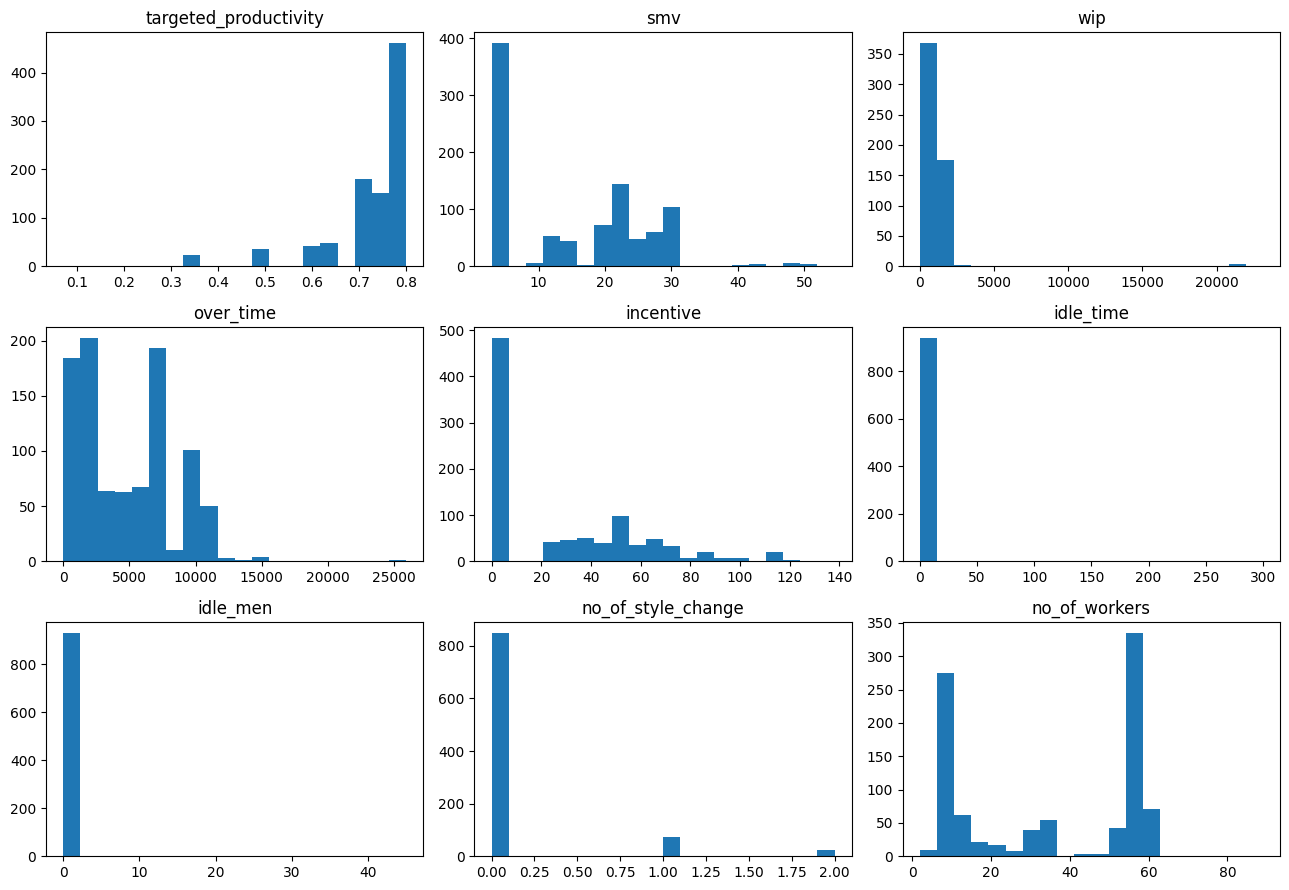

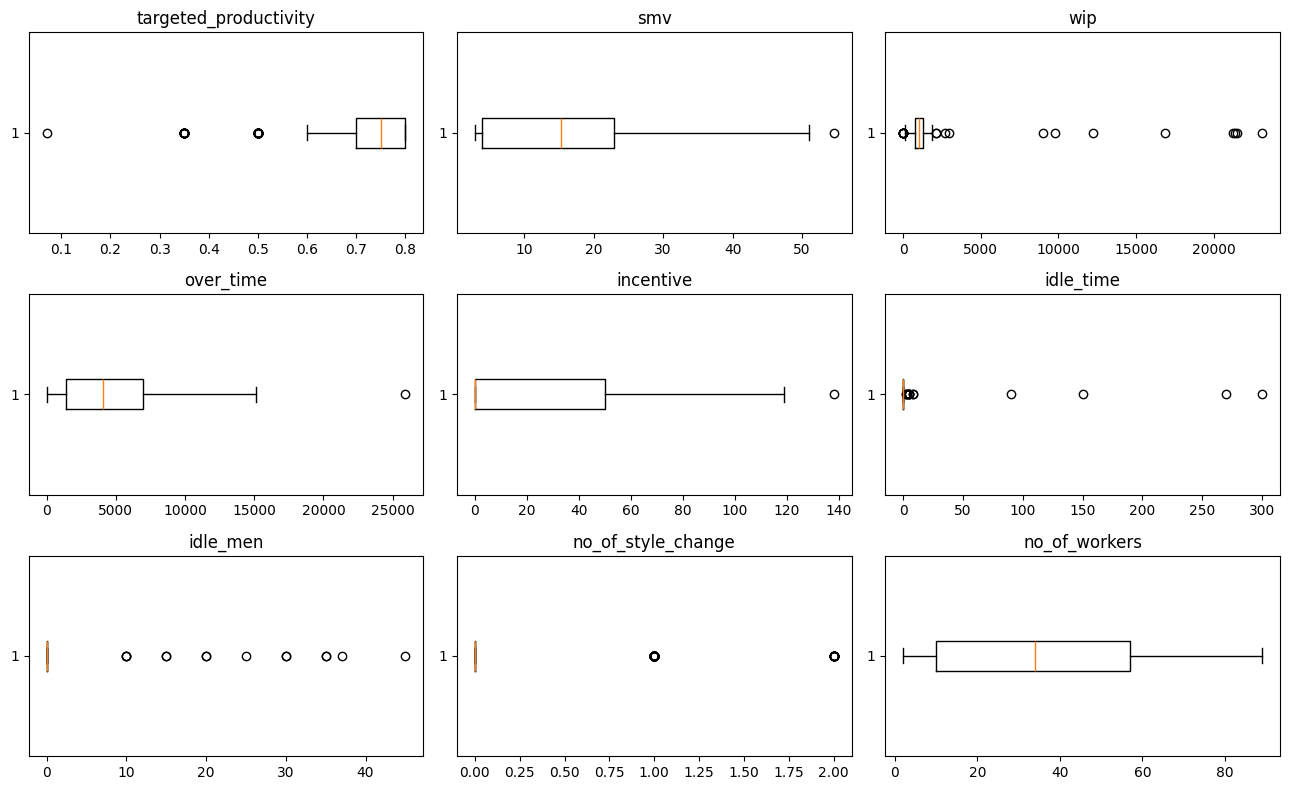

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.ravel()

for ax, c in zip(axes, numericas_v1):
    ax.hist(df_dev[c].dropna(), bins=20)
    ax.set_title(c)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, c in zip(axes, numericas_v1):
    ax.boxplot(df_dev[c].dropna(), vert=False)
    ax.set_title(c)

plt.tight_layout()
plt.show()


## 3. Pré-processamento

- Numéricas: `StandardScaler`
- Categóricas: `OneHotEncoder`

As transformações ficam dentro do `Pipeline` para evitar vazamento de dados.


In [36]:
numericas_v2 = [c for c in numericas_v1 if c != "wip"]
features_v1 = numericas_v1 + categoricas
features_v2 = numericas_v2 + categoricas

y_train = df_train["risco_meta"]
y_val = df_val["risco_meta"]
y_dev = df_dev["risco_meta"]
y_test = df_test["risco_meta"]

def criar_preprocessador(nums, cats=categoricas, scaler=None, encoder=None, denso=False):
    scaler = StandardScaler() if scaler is None else scaler
    encoder = OneHotEncoder(handle_unknown="ignore") if encoder is None else encoder

    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", scaler)
        ]), nums),

        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", encoder)
        ]), cats)
    ], sparse_threshold=0 if denso else 0.3)

def medir(y, pred, nome):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    }

metricas_cv = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}


# 4. Regressão Logística

A primeira versão utiliza todas as variáveis.

Na segunda versão, `WIP` é removida por apresentar muitos valores ausentes.


,Modelo,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
0,Baseline,0.5928,0.0000,0.0000,0.0000,0,0,79,115
1,"V1 - limiar 0,50",0.6237,0.5833,0.2658,0.3652,21,15,58,100
2,"V1 - limiar 0,20",0.6907,0.5905,0.7848,0.6739,62,43,17,72
3,V2 - sem WIP,0.7062,0.6019,0.8228,0.6952,65,43,14,72


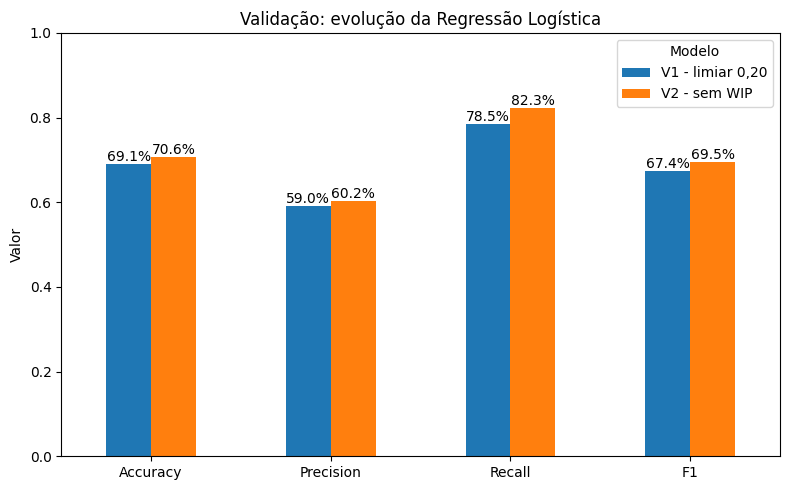

In [37]:
# V1
modelo_v1 = Pipeline([
    ("prep", criar_preprocessador(numericas_v1)),
    ("logit", LogisticRegression(C=1, solver="lbfgs", max_iter=1000))
]).fit(df_train[features_v1], y_train)

prob_v1 = modelo_v1.predict_proba(df_val[features_v1])[:, 1]

# V2
modelo_v2 = Pipeline([
    ("prep", criar_preprocessador(numericas_v2)),
    ("logit", LogisticRegression(C=1, solver="lbfgs", max_iter=1000))
]).fit(df_train[features_v2], y_train)

prob_v2 = modelo_v2.predict_proba(df_val[features_v2])[:, 1]

# Baseline e principais resultados
baseline = DummyClassifier(strategy="most_frequent").fit(
    df_train[features_v1], y_train
)

tabela_v1_v2 = pd.DataFrame([
    medir(y_val, baseline.predict(df_val[features_v1]), "Baseline"),
    medir(y_val, (prob_v1 >= 0.50).astype(int), "V1 - limiar 0,50"),
    medir(y_val, (prob_v1 >= 0.20).astype(int), "V1 - limiar 0,20"),
    medir(y_val, (prob_v2 >= 0.20).astype(int), "V2 - sem WIP")
])

display(tabela_v1_v2.round(4))

# Comparação entre V1 e V2
comp = tabela_v1_v2[
    tabela_v1_v2["Modelo"].isin(["V1 - limiar 0,20", "V2 - sem WIP"])
].set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]].T

ax = comp.plot(kind="bar", figsize=(8, 5))
ax.set_title("Validação: evolução da Regressão Logística")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", labels=[
        f"{v*100:.1f}%" for v in container.datavalues
    ])

plt.tight_layout()
plt.show()


### Regularização e limiar

São comparados diferentes valores de `C` usando `TimeSeriesSplit`.

Depois são testados alguns limiares para observar o equilíbrio entre Precision, Recall, FP e FN.


In [38]:
# Recria o conjunto usado na análise original do parâmetro C
df_dev_c = df[
    df["date"] < pd.Timestamp("2015-02-26")
].copy()

df_dev_c = (
    df_dev_c
    .sort_values("date")
    .reset_index(drop=True)
)

# Treino usado antes da validação temporal
df_train_c = df_dev_c[
    df_dev_c["date"] < pd.Timestamp("2015-02-14")
].copy()

y_train_c = df_train_c["risco_meta"]


# GridSearch
busca_logistica_c = GridSearchCV(
    Pipeline([
        (
            "prep",
            criar_preprocessador(numericas_v2)
        ),
        (
            "logit",
            LogisticRegression(
                solver="lbfgs",
                max_iter=1000
            )
        )
    ]),

    {
        "logit__C": [0.1, 1.0, 10.0]
    },

    scoring=metricas_cv,
    refit="f1",
    cv=TimeSeriesSplit(n_splits=5),
    return_train_score=True
)


busca_logistica_c.fit(
    df_train_c[features_v2],
    y_train_c
)


# Resultados
rlog_c = pd.DataFrame(
    busca_logistica_c.cv_results_
)

tabela_c = rlog_c[[
    "param_logit__C",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1"
]].copy()

tabela_c.columns = [
    "C",
    "Precision média CV",
    "Recall médio CV",
    "F1 médio CV"
]

display(tabela_c.round(4))

,C,Precision média CV,Recall médio CV,F1 médio CV
0,0.1,0.4619,0.1013,0.1603
1,1.0,0.5832,0.4096,0.4726
2,10.0,0.6113,0.3791,0.4342


### Testes de variáveis e outliers

Algumas variáveis são retiradas separadamente para verificar o impacto nas métricas.

Também é testado clipping por IQR em `over_time` e `incentive`.


In [39]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, fator=1.5, limite_minimo=0):
        self.fator = fator
        self.limite_minimo = limite_minimo

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1 = np.percentile(X, 25, axis=0)
        q3 = np.percentile(X, 75, axis=0)
        iqr = q3 - q1
        self.li_ = q1 - self.fator * iqr
        self.ls_ = q3 + self.fator * iqr
        if self.limite_minimo is not None:
            self.li_ = np.maximum(self.li_, self.limite_minimo)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.li_, self.ls_)

def avaliar_logistica(nums, cats=categoricas, limiar=0.20, nome=""):
    feats = nums + cats
    modelo = Pipeline([
        ("prep", criar_preprocessador(nums, cats)),
        ("logit", LogisticRegression(C=1, solver="lbfgs", max_iter=1000))
    ]).fit(df_train[feats], y_train)

    prob = modelo.predict_proba(df_val[feats])[:, 1]
    return medir(y_val, (prob >= limiar).astype(int), nome)

# V3: sem WIP + clipping IQR
clip_cols = ["over_time", "incentive"]
num_normais = [c for c in numericas_v2 if c not in clip_cols]

prep_v3 = ColumnTransformer([
    ("clip", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("iqr", IQRClipper()),
        ("scale", StandardScaler())
    ]), clip_cols),

    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), num_normais),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore"))
    ]), categoricas)
])

modelo_v3 = Pipeline([
    ("prep", prep_v3),
    ("logit", LogisticRegression(C=1, solver="lbfgs", max_iter=1000))
]).fit(df_train[features_v2], y_train)

pred_v3 = (
    modelo_v3.predict_proba(df_val[features_v2])[:, 1] >= 0.20
).astype(int)

resultados_ab = [
    medir(y_val, (prob_v1 >= 0.20).astype(int), "V1 - original"),
    medir(y_val, (prob_v2 >= 0.20).astype(int), "V2 - sem WIP"),
    medir(y_val, pred_v3, "V3 - sem WIP + clipping IQR"),
    avaliar_logistica(
        [c for c in numericas_v2 if c != "incentive"],
        nome="V4 - sem WIP e incentive"
    ),
    avaliar_logistica(
        [c for c in numericas_v2 if c != "no_of_workers"],
        nome="V5 - sem WIP e no_of_workers"
    ),
    avaliar_logistica(
        numericas_v2,
        [c for c in categoricas if c != "team"],
        limiar=0.20,
        nome="V6 - sem WIP e team"
    ),
    avaliar_logistica(
        numericas_v2,
        [c for c in categoricas if c != "department"],
        limiar=0.20,
        nome="V7 - sem WIP e department"
    )
]

tabela_ablacao = pd.DataFrame(resultados_ab)
display(tabela_ablacao.round(4))

# Limites aprendidos no treino para a V3
iqr_fit = (
    modelo_v3.named_steps["prep"]
             .named_transformers_["clip"]
             .named_steps["iqr"]
)

display(pd.DataFrame({
    "Variável": clip_cols,
    "Limite inferior": iqr_fit.li_,
    "Limite superior": iqr_fit.ls_
}).round(2))


,Modelo,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
0,V1 - original,0.6907,0.5905,0.7848,0.6739,62,43,17,72
1,V2 - sem WIP,0.7062,0.6019,0.8228,0.6952,65,43,14,72
2,V3 - sem WIP + clipping IQR,0.6907,0.5856,0.8228,0.6842,65,46,14,69
3,V4 - sem WIP e incentive,0.6392,0.5474,0.6582,0.5977,52,43,27,72
4,V5 - sem WIP e no_of_workers,0.6856,0.5804,0.8228,0.6806,65,47,14,68
5,V6 - sem WIP e team,0.7113,0.5966,0.8987,0.7172,71,48,8,67
6,V7 - sem WIP e department,0.7062,0.6000,0.8354,0.6984,66,44,13,71


,Variável,Limite inferior,Limite superior
0,over_time,0.0,15540.0
1,incentive,0.0,125.0


# 5. KNN

O KNN utiliza as mesmas features e o mesmo pré-processamento da versão final da Regressão Logística.

A busca compara diferentes valores de K, métricas de distância e tipos de peso.

Para manter o mesmo resultado entre execuções, a configuração principal fixa `algorithm="kd_tree"` e `leaf_size=100`.


Melhor configuração: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
F1 médio CV: 0.5324


,K,Distância,Pesos,Accuracy,Precision,Recall,F1
0,3,euclidean,uniform,0.7952,0.5785,0.4971,0.5324
1,3,euclidean,distance,0.7919,0.5706,0.4853,0.5204
12,3,manhattan,uniform,0.7871,0.5716,0.4275,0.4849
2,5,euclidean,uniform,0.7935,0.5967,0.4046,0.4736
4,7,euclidean,uniform,0.7903,0.5900,0.3873,0.4645
13,3,manhattan,distance,0.7790,0.5515,0.4034,0.4607
3,5,euclidean,distance,0.7887,0.5791,0.3870,0.4535
5,7,euclidean,distance,0.7855,0.5756,0.3696,0.4458
14,5,manhattan,uniform,0.7855,0.5859,0.3495,0.4323
6,9,euclidean,uniform,0.7952,0.6098,0.3345,0.4297


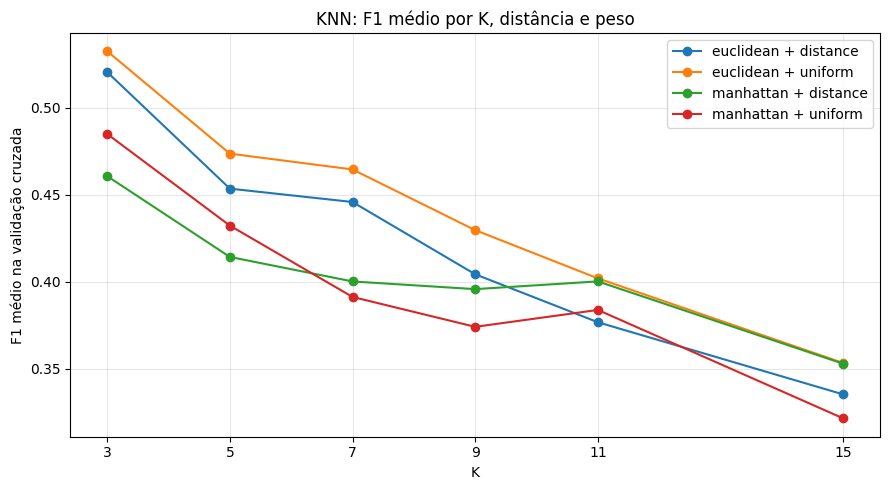

In [40]:
modelo_knn = Pipeline([
    ("prep", criar_preprocessador(numericas_v2)),
    ("knn", KNeighborsClassifier(
        algorithm="kd_tree",
        leaf_size=100
    ))
])

parametros_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__metric": ["euclidean", "manhattan"],
    "knn__weights": ["uniform", "distance"]
}

busca_knn = GridSearchCV(
    modelo_knn,
    parametros_knn,
    scoring=metricas_cv,
    refit="f1",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1
)

busca_knn.fit(df_train[features_v2], y_train)

rknn = pd.DataFrame(busca_knn.cv_results_)

tabela_knn = rknn[[
    "param_knn__n_neighbors",
    "param_knn__metric",
    "param_knn__weights",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1"
]].rename(columns={
    "param_knn__n_neighbors": "K",
    "param_knn__metric": "Distância",
    "param_knn__weights": "Pesos",
    "mean_test_accuracy": "Accuracy",
    "mean_test_precision": "Precision",
    "mean_test_recall": "Recall",
    "mean_test_f1": "F1"
}).sort_values("F1", ascending=False)

print("Melhor configuração:", busca_knn.best_params_)
print("F1 médio CV:", round(busca_knn.best_score_, 4))
display(tabela_knn.head(10).round(4))

# Gráfico de K x F1 para cada combinação
grafico_k = tabela_knn.copy()
grafico_k["Combinação"] = (
    grafico_k["Distância"].astype(str) + " + " +
    grafico_k["Pesos"].astype(str)
)

plt.figure(figsize=(9, 5))

for nome, grupo in grafico_k.groupby("Combinação"):
    grupo = grupo.sort_values("K")
    plt.plot(grupo["K"], grupo["F1"], marker="o", label=nome)

plt.title("KNN: F1 médio por K, distância e peso")
plt.xlabel("K")
plt.ylabel("F1 médio na validação cruzada")
plt.xticks([3, 5, 7, 9, 11, 15])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Limiar do KNN

Com `K=3` e pesos uniformes, as probabilidades são discretas.

O limiar é ajustado para melhorar a identificação da classe de risco.


In [41]:
melhor_knn = busca_knn.best_estimator_
prob_knn = melhor_knn.predict_proba(df_val[features_v2])[:, 1]

print("Probabilidades possíveis:",
      np.unique(np.round(prob_knn, 4)))

tabela_limiar_knn = pd.DataFrame([
    medir(y_val, (prob_knn >= 0.50).astype(int), "KNN - limiar 0,50"),
    medir(y_val, (prob_knn >= 0.33).astype(int), "KNN - limiar 0,33")
])

display(tabela_limiar_knn.round(4))


Probabilidades possíveis: [0.     0.3333 0.6667 1.    ]


,Modelo,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
0,"KNN - limiar 0,50",0.6443,0.6250,0.3165,0.4202,25,15,54,100
1,"KNN - limiar 0,33",0.6598,0.5575,0.7975,0.6562,63,50,16,65


### Testes adicionais do KNN

Também são avaliadas outras escalas, redução de atributos, diferentes codificações e PCA.

O objetivo é verificar se mudanças na representação dos dados melhoram a vizinhança do KNN.


In [42]:
def buscar_knn(nums, cats, scaler=None, encoder=None, componentes=None):
    feats = nums + cats

    prep = criar_preprocessador(
        nums,
        cats,
        scaler=scaler,
        encoder=encoder,
        denso=componentes is not None
    )

    passos = [("prep", prep)]

    grade = {
        "knn__n_neighbors": list(range(1, 32, 2)),
        "knn__metric": ["euclidean", "manhattan"],
        "knn__weights": ["uniform", "distance"]
    }

    if componentes is not None:
        passos.append(("pca", PCA()))
        grade["pca__n_components"] = componentes

    passos.append(("knn", KNeighborsClassifier()))

    busca = GridSearchCV(
        Pipeline(passos),
        grade,
        scoring=metricas_cv,
        refit="f1",
        cv=TimeSeriesSplit(n_splits=5),
        n_jobs=-1
    )

    busca.fit(df_train[feats], y_train)
    pred = busca.best_estimator_.predict(df_val[feats])

    resultado = medir(y_val, pred, "")
    return busca, resultado

experimentos_knn = []

# Referência
ref = medir(
    y_val,
    melhor_knn.predict(df_val[features_v2]),
    "One-Hot + StandardScaler"
)
experimentos_knn.append({
    "Experimento": "One-Hot + StandardScaler",
    "Dimensões": melhor_knn.named_steps["prep"]
                          .transform(df_train[features_v2]).shape[1],
    "Melhor configuração": str(busca_knn.best_params_),
    "F1 médio CV": busca_knn.best_score_,
    "F1 natural": ref["F1"]
})

# Menos três variáveis
nums_reduzidas = [
    c for c in numericas_v2
    if c not in ["idle_time", "idle_men", "no_of_style_change"]
]
b, r = buscar_knn(nums_reduzidas, categoricas)
experimentos_knn.append({
    "Experimento": "Sem idle_time, idle_men e style_change",
    "Dimensões": b.best_estimator_.named_steps["prep"]
                  .transform(df_train[nums_reduzidas + categoricas]).shape[1],
    "Melhor configuração": str(b.best_params_),
    "F1 médio CV": b.best_score_,
    "F1 natural": r["F1"]
})

# Escalas
for nome, scaler in [
    ("MinMaxScaler", MinMaxScaler()),
    ("RobustScaler", RobustScaler())
]:
    b, r = buscar_knn(numericas_v2, categoricas, scaler=scaler)
    experimentos_knn.append({
        "Experimento": nome,
        "Dimensões": b.best_estimator_.named_steps["prep"]
                      .transform(df_train[features_v2]).shape[1],
        "Melhor configuração": str(b.best_params_),
        "F1 médio CV": b.best_score_,
        "F1 natural": r["F1"]
    })

# One-Hot drop first
b_drop, r_drop = buscar_knn(
    numericas_v2,
    categoricas,
    encoder=OneHotEncoder(handle_unknown="ignore", drop="first")
)
experimentos_knn.append({
    "Experimento": "One-Hot drop first",
    "Dimensões": b_drop.best_estimator_.named_steps["prep"]
                  .transform(df_train[features_v2]).shape[1],
    "Melhor configuração": str(b_drop.best_params_),
    "F1 médio CV": b_drop.best_score_,
    "F1 natural": r_drop["F1"]
})

# Ordinal: depois da codificação, as categorias também são padronizadas
prep_ord = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numericas_v2),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )),
        ("scale", StandardScaler())
    ]), categoricas)
])

b_ord = GridSearchCV(
    Pipeline([
        ("prep", prep_ord),
        ("knn", KNeighborsClassifier())
    ]),
    {
        "knn__n_neighbors": list(range(1, 32, 2)),
        "knn__metric": ["euclidean", "manhattan"],
        "knn__weights": ["uniform", "distance"]
    },
    scoring=metricas_cv,
    refit="f1",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1
).fit(df_train[features_v2], y_train)

pred_ord = b_ord.best_estimator_.predict(df_val[features_v2])
r_ord = medir(y_val, pred_ord, "")

experimentos_knn.append({
    "Experimento": "OrdinalEncoder",
    "Dimensões": b_ord.best_estimator_.named_steps["prep"]
                 .transform(df_train[features_v2]).shape[1],
    "Melhor configuração": str(b_ord.best_params_),
    "F1 médio CV": b_ord.best_score_,
    "F1 natural": r_ord["F1"]
})

# Somente numéricas
prep_num = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numericas_v2)
])

busca_num = GridSearchCV(
    Pipeline([
        ("prep", prep_num),
        ("knn", KNeighborsClassifier())
    ]),
    {
        "knn__n_neighbors": list(range(1, 32, 2)),
        "knn__metric": ["euclidean", "manhattan"],
        "knn__weights": ["uniform", "distance"]
    },
    scoring=metricas_cv,
    refit="f1",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1
).fit(df_train[numericas_v2], y_train)

pred_num = busca_num.best_estimator_.predict(df_val[numericas_v2])
r_num = medir(y_val, pred_num, "")

experimentos_knn.append({
    "Experimento": "Somente numéricas",
    "Dimensões": len(numericas_v2),
    "Melhor configuração": str(busca_num.best_params_),
    "F1 médio CV": busca_num.best_score_,
    "F1 natural": r_num["F1"]
})

# PCA
b_pca, r_pca = buscar_knn(
    numericas_v2,
    categoricas,
    componentes=[5, 8, 10, 12, 15, 20]
)

experimentos_knn.append({
    "Experimento": "One-Hot + PCA",
    "Dimensões": b_pca.best_params_["pca__n_components"],
    "Melhor configuração": str(b_pca.best_params_),
    "F1 médio CV": b_pca.best_score_,
    "F1 natural": r_pca["F1"]
})

tabela_experimentos_knn = pd.DataFrame(experimentos_knn)
display(tabela_experimentos_knn.round(4))


,Experimento,Dimensões,Melhor configuração,F1 médio CV,F1 natural
0,One-Hot + StandardScaler,33,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.5324,0.4202
1,"Sem idle_time, idle_men e style_change",30,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.5516,0.3540
2,MinMaxScaler,33,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.4663,0.2936
3,RobustScaler,33,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.4540,0.3393
4,One-Hot drop first,29,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.4884,0.4237
5,OrdinalEncoder,12,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.4334,0.4928
6,Somente numéricas,8,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.5697,0.5517
7,One-Hot + PCA,20,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.4806,0.4762


In [43]:
# Conferências adicionais do KNN

# weights="distance": quantidade de probabilidades e melhor F1 por limiar
knn_distance = Pipeline([
    ("prep", criar_preprocessador(numericas_v2)),
    ("knn", KNeighborsClassifier(
        n_neighbors=3,
        metric="euclidean",
        weights="distance"
    ))
]).fit(df_train[features_v2], y_train)

prob_distance = knn_distance.predict_proba(df_val[features_v2])[:, 1]
print("Probabilidades diferentes com weights='distance':",
      len(np.unique(np.round(prob_distance, 4))))

# Somente numéricas: limiar
prob_num = busca_num.best_estimator_.predict_proba(
    df_val[numericas_v2]
)[:, 1]

pred_num_036 = (prob_num >= 0.36).astype(int)
display(pd.DataFrame([
    medir(y_val, pred_num_036, "Somente numéricas - limiar 0,36")
]).round(4))

# PCA: variância e limiar
modelo_pca = b_pca.best_estimator_
prob_pca = modelo_pca.predict_proba(df_val[features_v2])[:, 1]

print("Componentes PCA:",
      modelo_pca.named_steps["pca"].n_components_)
print("Variância explicada:",
      round(modelo_pca.named_steps["pca"].explained_variance_ratio_.sum()*100, 2),
      "%")

pred_pca_010 = (prob_pca >= 0.10).astype(int)
display(pd.DataFrame([
    medir(y_val, pred_pca_010, "PCA - limiar 0,10")
]).round(4))


Probabilidades diferentes com weights='distance': 98


,Modelo,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
0,"Somente numéricas - limiar 0,36",0.6753,0.6111,0.557,0.5828,44,28,35,87


Componentes PCA: 20
Variância explicada: 95.32 %


,Modelo,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
0,"PCA - limiar 0,10",0.6443,0.541,0.8354,0.6567,66,56,13,59


# 6. Teste final e comparação

Depois da validação, os dois modelos são treinados com todo o conjunto de desenvolvimento e avaliados no mesmo conjunto de teste.


In [44]:
# Regressão Logística V2 final
logistica_final = Pipeline([
    ("prep", criar_preprocessador(numericas_v2)),
    ("logit", LogisticRegression(C=1, solver="lbfgs", max_iter=1000))
]).fit(df_dev[features_v2], y_dev)

prob_test_log = logistica_final.predict_proba(
    df_test[features_v2]
)[:, 1]
pred_test_log = (prob_test_log >= 0.20).astype(int)

# KNN final
knn_final = Pipeline([
    ("prep", criar_preprocessador(numericas_v2)),
    ("knn", KNeighborsClassifier(
        n_neighbors=3,
        metric="euclidean",
        weights="uniform",
        algorithm="kd_tree",
        leaf_size=100
    ))
]).fit(df_dev[features_v2], y_dev)

prob_test_knn = knn_final.predict_proba(
    df_test[features_v2]
)[:, 1]
pred_test_knn = (prob_test_knn >= 0.33).astype(int)

# Resultados finais dos modelos
resultado_log = medir(
    y_test, pred_test_log, "Regressão Logística V2"
)
resultado_knn = medir(
    y_test, pred_test_knn, "KNN"
)

comparacao_final = pd.DataFrame([
    resultado_log,
    resultado_knn
])

display(comparacao_final.round(4))

# Matrizes de confusão
for nome, pred in [
    ("Regressão Logística V2", pred_test_log),
    ("KNN", pred_test_knn)
]:
    matriz = pd.DataFrame(
        confusion_matrix(y_test, pred, labels=[0, 1]),
        index=["Real 0", "Real 1"],
        columns=["Previsto 0", "Previsto 1"]
    )
    print("\n", nome)
    display(matriz)


,Modelo,Accuracy,Precision,Recall,F1,TP,FP,FN,TN
0,Regressão Logística V2,0.6890,0.4522,0.7647,0.5683,52,63,16,123
1,KNN,0.5669,0.3521,0.7353,0.4762,50,92,18,94



 Regressão Logística V2


,Previsto 0,Previsto 1
Real 0,123,63
Real 1,16,52



 KNN


,Previsto 0,Previsto 1
Real 0,94,92
Real 1,18,50


### Interpretação da Regressão Logística

Os coeficientes ajudam a entender quais variáveis tiveram maior participação na decisão do modelo.

- coeficiente positivo: maior associação com a classe de risco;
- coeficiente negativo: menor associação com a classe de risco;
- maior valor absoluto: maior influência na decisão.

Essa leitura mostra associação no modelo, não relação de causa e efeito.


,Variável,Coeficiente,Magnitude,Direção
3,incentive,-2.2256,2.2256,Menor associação com risco
1,smv,1.1985,1.1985,Maior associação com risco
31,team_11,0.8666,0.8666,Maior associação com risco
7,no_of_workers,-0.8139,0.8139,Menor associação com risco
21,team_1,-0.7177,0.7177,Menor associação com risco
28,team_8,0.6956,0.6956,Maior associação com risco
23,team_3,-0.6141,0.6141,Menor associação com risco
18,day_thursday,0.5647,0.5647,Maior associação com risco
12,quarter_quarter5,-0.5418,0.5418,Menor associação com risco
29,team_9,0.5054,0.5054,Maior associação com risco


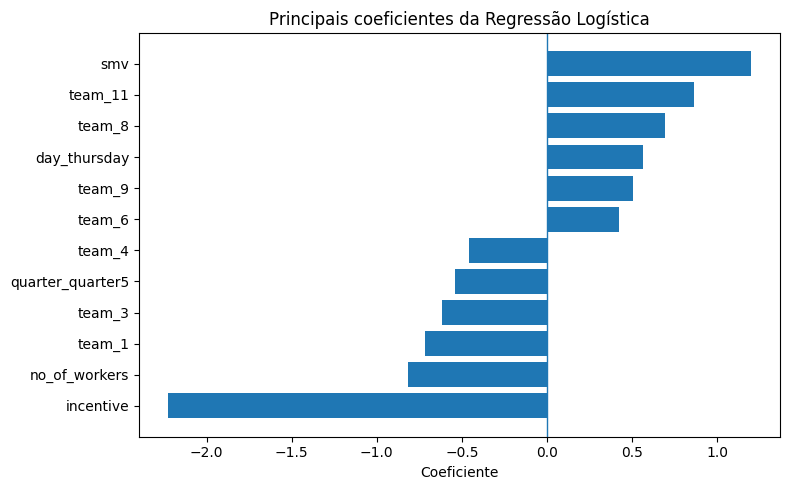

In [45]:
# Nomes das variáveis e coeficientes do modelo final
nomes_features = logistica_final.named_steps["prep"].get_feature_names_out()
coef = logistica_final.named_steps["logit"].coef_[0]

coeficientes = pd.DataFrame({
    "Variável": nomes_features,
    "Coeficiente": coef
})

coeficientes["Variável"] = (
    coeficientes["Variável"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coeficientes["Magnitude"] = coeficientes["Coeficiente"].abs()
coeficientes["Direção"] = np.where(
    coeficientes["Coeficiente"] > 0,
    "Maior associação com risco",
    "Menor associação com risco"
)

top_coef = coeficientes.sort_values("Magnitude", ascending=False).head(12)
display(top_coef.round(4))

# Gráfico dos coeficientes mais relevantes
grafico_coef = top_coef.sort_values("Coeficiente")
plt.figure(figsize=(8, 5))
plt.barh(grafico_coef["Variável"], grafico_coef["Coeficiente"])
plt.axvline(0, linewidth=1)
plt.title("Principais coeficientes da Regressão Logística")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()


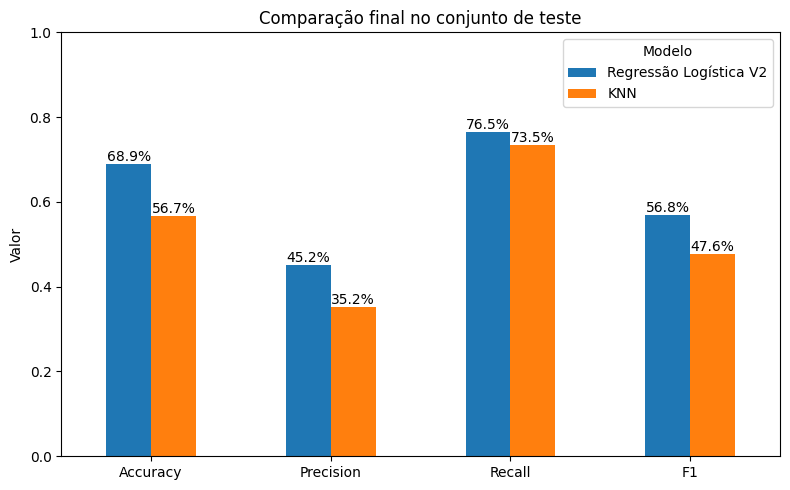

Diferença em pontos percentuais:


,p.p.
Accuracy,12.20
Precision,10.01
Recall,2.94
F1,9.21


Falsos positivos a mais no KNN: 29
Falsos negativos a mais no KNN: 2


In [46]:
# Comparação final das métricas
metricas_plot = ["Accuracy", "Precision", "Recall", "F1"]

plot_final = (
    comparacao_final
    .set_index("Modelo")[metricas_plot]
    .T
)

ax = plot_final.plot(kind="bar", figsize=(8, 5))
ax.set_title("Comparação final no conjunto de teste")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.1f}%" for v in container.datavalues]
    )

plt.tight_layout()
plt.show()

# Diferenças citadas no texto
dif = (
    comparacao_final
    .set_index("Modelo")
    .loc["Regressão Logística V2", metricas_plot]
    -
    comparacao_final
    .set_index("Modelo")
    .loc["KNN", metricas_plot]
) * 100

print("Diferença em pontos percentuais:")
display(dif.round(2).to_frame("p.p."))

print(
    "Falsos positivos a mais no KNN:",
    resultado_knn["FP"] - resultado_log["FP"]
)
print(
    "Falsos negativos a mais no KNN:",
    resultado_knn["FN"] - resultado_log["FN"]
)


## Exemplo de previsão

Para visualizar o funcionamento do modelo, selecionamos dois exemplos do conjunto de teste:

- um caso que atingiu a meta;
- um caso que não atingiu a meta.

A produtividade real é exibida apenas para conferir o resultado. Ela não é fornecida ao modelo durante a previsão.

In [47]:
# Probabilidades no conjunto de teste
demo = df_test.copy()

demo["prob_risco"] = logistica_final.predict_proba(
    demo[features_v2]
)[:, 1]

# Limiar final da Regressão Logística
demo["previsao"] = (
    demo["prob_risco"] >= 0.20
).astype(int)

# Um exemplo de cada classe corretamente previsto
atingiu = demo[
    (demo["risco_meta"] == 0) &
    (demo["previsao"] == 0)
].iloc[[0]]

nao_atingiu = demo[
    (demo["risco_meta"] == 1) &
    (demo["previsao"] == 1)
].iloc[[0]]

exemplos = pd.concat([
    atingiu,
    nao_atingiu
])

display(
    exemplos[[
        "date",
        "department",
        "team",
        "targeted_productivity",
        "actual_productivity",
        "smv",
        "over_time",
        "incentive",
        "no_of_workers"
    ]]
)

,date,department,team,targeted_productivity,actual_productivity,smv,over_time,incentive,no_of_workers
946,2015-02-26,sweing,5,0.35,0.449965,27.48,6840,38,57.0
943,2015-02-26,finishing,12,0.80,0.590617,4.60,3780,0,9.0


In [48]:
for _, linha in exemplos.iterrows():

    dados = linha[features_v2].to_frame().T

    prob = logistica_final.predict_proba(
        dados
    )[0, 1]

    previsto = int(prob >= 0.20)

    print("-" * 45)

    print(
        "Meta:",
        round(linha["targeted_productivity"], 3)
    )

    print(
        "Produtividade real:",
        round(linha["actual_productivity"], 3)
    )

    print(
        "Resultado real:",
        "NÃO ATINGIU" if linha["risco_meta"] == 1
        else "ATINGIU"
    )

    print(
        "Probabilidade de risco:",
        f"{prob:.2%}"
    )

    print(
        "Previsão do modelo:",
        "NÃO VAI ATINGIR" if previsto == 1
        else "VAI ATINGIR"
    )

---------------------------------------------
Meta: 0.35
Produtividade real: 0.45
Resultado real: ATINGIU
Probabilidade de risco: 5.73%
Previsão do modelo: VAI ATINGIR
---------------------------------------------
Meta: 0.8
Produtividade real: 0.591
Resultado real: NÃO ATINGIU
Probabilidade de risco: 58.91%
Previsão do modelo: NÃO VAI ATINGIR


## Referências utilizadas

- **Ananthi et al. (2026):** mesmo dataset, KNN, Grid Search e escalonamento.
- **Biswas, Shahzamal e Haque (2024):** remoção de WIP, IQR, One-Hot e análise de correlação.
- **Materiais da disciplina:** Regressão Logística, KNN e métricas de classificação.

Os artigos trabalham principalmente com regressão. Neste projeto o problema foi adaptado para classificação binária.
